In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import lightgbm as lgb
import optuna 
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

In [2]:
df_raw = pd.read_csv("abalone.data.csv", sep = ',')
print(df_raw.head())

  gender  Length  Diameter  Height  Whole weight  Shucked weight  \
0      M   0.455     0.365   0.095        0.5140          0.2245   
1      M   0.350     0.265   0.090        0.2255          0.0995   
2      F   0.530     0.420   0.135        0.6770          0.2565   
3      M   0.440     0.365   0.125        0.5160          0.2155   
4      I   0.330     0.255   0.080        0.2050          0.0895   

   Viscera weight  Shell weight  Rings  
0          0.1010         0.150     15  
1          0.0485         0.070      7  
2          0.1415         0.210      9  
3          0.1140         0.155     10  
4          0.0395         0.055      7  


In [3]:
df_encoded = pd.get_dummies(df_raw)
print(df_encoded.head())

   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  gender_F  gender_I  gender_M  
0         0.150     15     False     False      True  
1         0.070      7     False     False      True  
2         0.210      9      True     False     False  
3         0.155     10     False     False      True  
4         0.055      7     False      True     False  


In [4]:
df_encoded = df_encoded[df_encoded['Height'] > 0]
df_encoded[['Shucked weight', 'Viscera weight', 'Shell weight']] = df_encoded[['Shucked weight', 'Viscera weight', 'Shell weight']].div(df_encoded['Whole weight'], axis = 0)
df_encoded['weight_to_height'] = df_encoded['Whole weight'].div(df_encoded['Height'], axis = 0)
df_encoded['weight_to_length'] = df_encoded['Whole weight'].div(df_encoded['Length'], axis = 0)
df_encoded['weight_to_diameter'] = df_encoded['Whole weight'].div(df_encoded['Diameter'], axis = 0)
df_encoded.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,gender_F,gender_I,gender_M,weight_to_height,weight_to_length,weight_to_diameter
0,0.455,0.365,0.095,0.5140,0.436770,0.196498,0.291829,15,False,False,True,5.410526,1.129670,1.408219
1,0.350,0.265,0.090,0.2255,0.441242,0.215078,0.310421,7,False,False,True,2.505556,0.644286,0.850943
2,0.530,0.420,0.135,0.6770,0.378877,0.209010,0.310192,9,True,False,False,5.014815,1.277358,1.611905
3,0.440,0.365,0.125,0.5160,0.417636,0.220930,0.300388,10,False,False,True,4.128000,1.172727,1.413699
4,0.330,0.255,0.080,0.2050,0.436585,0.192683,0.268293,7,False,True,False,2.562500,0.621212,0.803922


In [5]:
df_encoded.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,weight_to_height,weight_to_length,weight_to_diameter
count,4175.000000,4175.00000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000
mean,0.524065,0.40794,0.139583,0.829005,0.432403,0.218542,0.295055,9.935090,5.462290,1.446345,1.852879
std,0.120069,0.09922,0.041725,0.490349,0.105787,0.034368,0.046555,3.224227,2.550646,0.638765,0.799688
min,0.075000,0.05500,0.010000,0.002000,0.175258,0.007634,0.109341,1.000000,0.200000,0.026667,0.036364
25%,0.450000,0.35000,0.115000,0.442250,0.395093,0.198584,0.266073,8.000000,3.738871,0.967251,1.260256
50%,0.545000,0.42500,0.140000,0.800000,0.430592,0.217259,0.290870,9.000000,5.476667,1.461818,1.873626
75%,0.615000,0.48000,0.165000,1.153500,0.466170,0.236949,0.319410,11.000000,7.061344,1.886454,2.404167
max,0.815000,0.65000,1.130000,2.825500,4.691943,0.665399,0.935361,29.000000,77.100000,3.870548,4.748739


In [6]:
sanity_check = df_encoded['Shucked weight'] + df_encoded['Viscera weight'] + df_encoded['Shell weight'] <= 1
df_encoded = df_encoded[sanity_check]
df_encoded = df_encoded.drop(index = df_encoded[df_encoded['weight_to_height'] > 77].index)

In [7]:
df_encoded = df_encoded.drop(columns = ['Diameter', 'weight_to_diameter'])

In [8]:
df_encoded.head()

,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,gender_F,gender_I,gender_M,weight_to_height,weight_to_length
0,0.455,0.095,0.5140,0.436770,0.196498,0.291829,15,False,False,True,5.410526,1.129670
1,0.350,0.090,0.2255,0.441242,0.215078,0.310421,7,False,False,True,2.505556,0.644286
2,0.530,0.135,0.6770,0.378877,0.209010,0.310192,9,True,False,False,5.014815,1.277358
3,0.440,0.125,0.5160,0.417636,0.220930,0.300388,10,False,False,True,4.128000,1.172727
4,0.330,0.080,0.2050,0.436585,0.192683,0.268293,7,False,True,False,2.562500,0.621212


In [23]:
"""
y = df_encoded_full['Rings']
X = df_encoded_full.drop(columns = 'Rings')
"""
X = df_encoded.drop(columns = 'Rings')
y = df_encoded['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_round = 200

In [24]:
def objective(trial):
    # Hyperparameter search space
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42,
        'verbose': -1
    }

    # Train/validation on your existing split
    model_inner = lgb.LGBMRegressor(
        n_estimators=1000,
        **params
    )
    model_inner.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    y_pred = model_inner.predict(X_test, num_iteration=model_inner.best_iteration_)
    return r2_score(y_test, y_pred)  # maximize R² on raw Rings


# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best R² on validation:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-24 22:46:30,941] A new study created in memory with name: no-name-70ed9c29-c3f1-47c6-b410-cfcdb8420bda


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-24 22:46:31,002] Trial 0 finished with value: 0.6084516148390323 and parameters: {'num_leaves': 82, 'learning_rate': 0.10545124389858812, 'feature_fraction': 0.6742544978941459, 'bagging_fraction': 0.7738382130289685, 'bagging_freq': 4, 'min_child_samples': 94, 'reg_alpha': 4.311662607801529, 'reg_lambda': 0.20208338430119321}. Best is trial 0 with value: 0.6084516148390323.
[I 2026-01-24 22:46:31,051] Trial 1 finished with value: 0.6115567509237223 and parameters: {'num_leaves': 32, 'learning_rate': 0.10431581148404888, 'feature_fraction': 0.8367060645471746, 'bagging_fraction': 0.7096791329716603, 'bagging_freq': 4, 'min_child_samples': 25, 'reg_alpha': 0.8631154988743167, 'reg_lambda': 3.8830364814341904}. Best is trial 1 with value: 0.6115567509237223.
[I 2026-01-24 22:46:31,120] Trial 2 finished with value: 0.6038670601474159 and parameters: {'num_leaves': 67, 'learning_rate': 0.14019565527219058, 'feature_fraction': 0.8528290027675358, 'bagging_fraction': 0.76839358940

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[I 2026-01-24 22:46:37,572] Trial 45 finished with value: 0.6122153288059589 and parameters: {'num_leaves': 74, 'learning_rate': 0.01182702453020181, 'feature_fraction': 0.685517201530533, 'bagging_fraction': 0.8079037409791473, 'bagging_freq': 4, 'min_child_samples': 78, 'reg_alpha': 4.395875004881423, 'reg_lambda': 4.929383005711362}. Best is trial 11 with value: 0.6168339488007062.
[I 2026-01-24 22:46:37,721] Trial 46 finished with value: 0.6154291663945918 and parameters: {'num_leaves': 136, 'learning_rate': 0.015301679226371545, 'feature_fraction': 0.7228079925884272, 'bagging_fraction': 0.7613276927471444, 'bagging_freq': 7, 'min_child_samples': 83, 'reg_alpha': 4.990435983241444, 'reg_lambda': 0.07910132997827457}. Best is trial 11 with value: 0.6168339488007062.


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-24 22:46:37,860] Trial 47 finished with value: 0.6130178539684108 and parameters: {'num_leaves': 50, 'learning_rate': 0.021675307973152053, 'feature_fraction': 0.7687870656320919, 'bagging_fraction': 0.9302930643772487, 'bagging_freq': 2, 'min_child_samples': 97, 'reg_alpha': 3.461305241538054, 'reg_lambda': 3.6874526925017683}. Best is trial 11 with value: 0.6168339488007062.


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-24 22:46:38,112] Trial 48 finished with value: 0.6018124624423237 and parameters: {'num_leaves': 146, 'learning_rate': 0.028532898628318128, 'feature_fraction': 0.847139064680181, 'bagging_fraction': 0.9559969788355684, 'bagging_freq': 1, 'min_child_samples': 18, 'reg_alpha': 0.17228672503039588, 'reg_lambda': 4.165813264534794}. Best is trial 11 with value: 0.6168339488007062.
[I 2026-01-24 22:46:38,225] Trial 49 finished with value: 0.6107881994422681 and parameters: {'num_leaves': 98, 'learning_rate': 0.039431134530734886, 'feature_fraction': 0.6689291066876405, 'bagging_fraction': 0.9802392829302274, 'bagging_freq': 6, 'min_child_samples': 85, 'reg_alpha': 0.6947081374695706, 'reg_lambda': 2.8459042169755784}. Best is trial 11 with value: 0.6168339488007062.
Best R² on validation: 0.6168339488007062
Best params: {'num_leaves': 150, 'learning_rate': 0.02530037425932405, 'feature_fraction': 0.7165354582186125, 'bagging_fraction': 0.9930996177594962, 'bagging_freq': 7, 'min

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.08175
[200]	valid_0's rmse: 2.04827
Early stopping, best iteration is:
[183]	valid_0's rmse: 2.04638
RMSE: 2.0464, R²: 0.6168


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


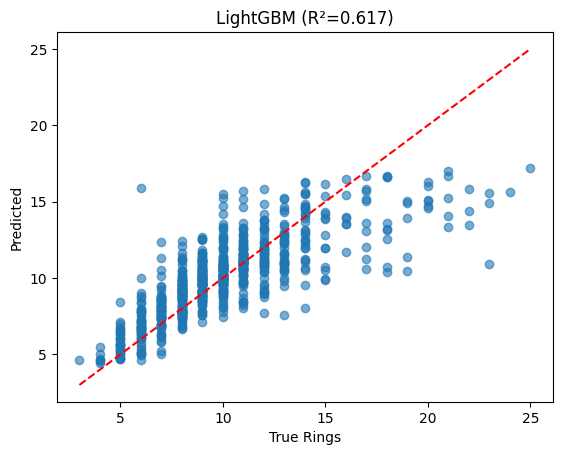

In [26]:

best_params = study.best_params

best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = lgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()

R2 best is 0.6175, RMSE best is 2.0446, can't remove data///
Check residuals for non-linearity

In [20]:
df = df_encoded.drop(columns = ['Shucked weight', 'Viscera weight', 
'Shell weight', 'weight_to_height', 'weight_to_length'])

[I 2026-01-24 21:34:44,626] A new study created in memory with name: no-name-c35ae2a5-2773-44fc-8b0d-b59472a758a1
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-01-24 21:34:44,713] Trial 0 finished with value: 0.366954655216582 and parameters: {'num_leaves': 140, 'learning_rate': 0.0554767429782693, 'feature_fraction': 0.6561486432053102, 'bagging_fraction': 0.940092639190035, 'bagging_freq': 6, 'min_child_samples': 18, 'reg_alpha': 3.8751371255973304, 'reg_lambda': 0.13171693981009813}. Best is trial 0 with value: 0.366954655216582.
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-01-24 21:34:44,823] Trial 1 finished with value

Best R² on validation: 0.6175132765749491
Best params: {'num_leaves': 146, 'learning_rate': 0.012169079903155348, 'feature_fraction': 0.793853755790265, 'bagging_fraction': 0.9913663166710578, 'bagging_freq': 6, 'min_child_samples': 100, 'reg_alpha': 2.4767254419212517, 'reg_lambda': 1.1377101071316678}
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.67975
[200]	valid_0's rmse: 2.60428
[300]	valid_0's rmse: 2.5956
Early stopping, best iteration is:
[301]	valid_0's rmse: 2.59547
RMSE: 2.5955, R²: 0.3836


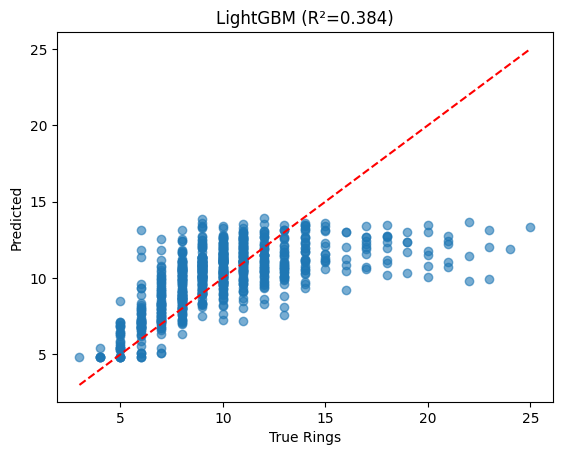

In [22]:
X = df.drop(columns = 'Rings')
y = df['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_round = 200

study_pure = optuna.create_study(direction='maximize')
study_pure.optimize(objective, n_trials=50)

print("Best R² on validation:", study.best_value)
print("Best params:", study.best_params)

best_params_pure = study_pure.best_params

best_params_pure.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model_pure = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params
)

lgb_model_pure.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = lgb_model_pure.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()

In [28]:
X

,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,gender_F,gender_I,gender_M,weight_to_height,weight_to_length
0,0.455,0.095,0.5140,0.436770,0.196498,0.291829,False,False,True,5.410526,1.129670
1,0.350,0.090,0.2255,0.441242,0.215078,0.310421,False,False,True,2.505556,0.644286
2,0.530,0.135,0.6770,0.378877,0.209010,0.310192,True,False,False,5.014815,1.277358
3,0.440,0.125,0.5160,0.417636,0.220930,0.300388,False,False,True,4.128000,1.172727
4,0.330,0.080,0.2050,0.436585,0.192683,0.268293,False,True,False,2.562500,0.621212
...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.165,0.8870,0.417136,0.269448,0.280722,True,False,False,5.375758,1.569912
4173,0.590,0.135,0.9660,0.454451,0.222050,0.269669,False,False,True,7.155556,1.637288
4174,0.600,0.205,1.1760,0.446854,0.244473,0.261905,False,False,True,5.736585,1.960000
4175,0.625,0.150,1.0945,0.485153,0.238465,0.270443,True,False,False,7.296667,1.751200


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

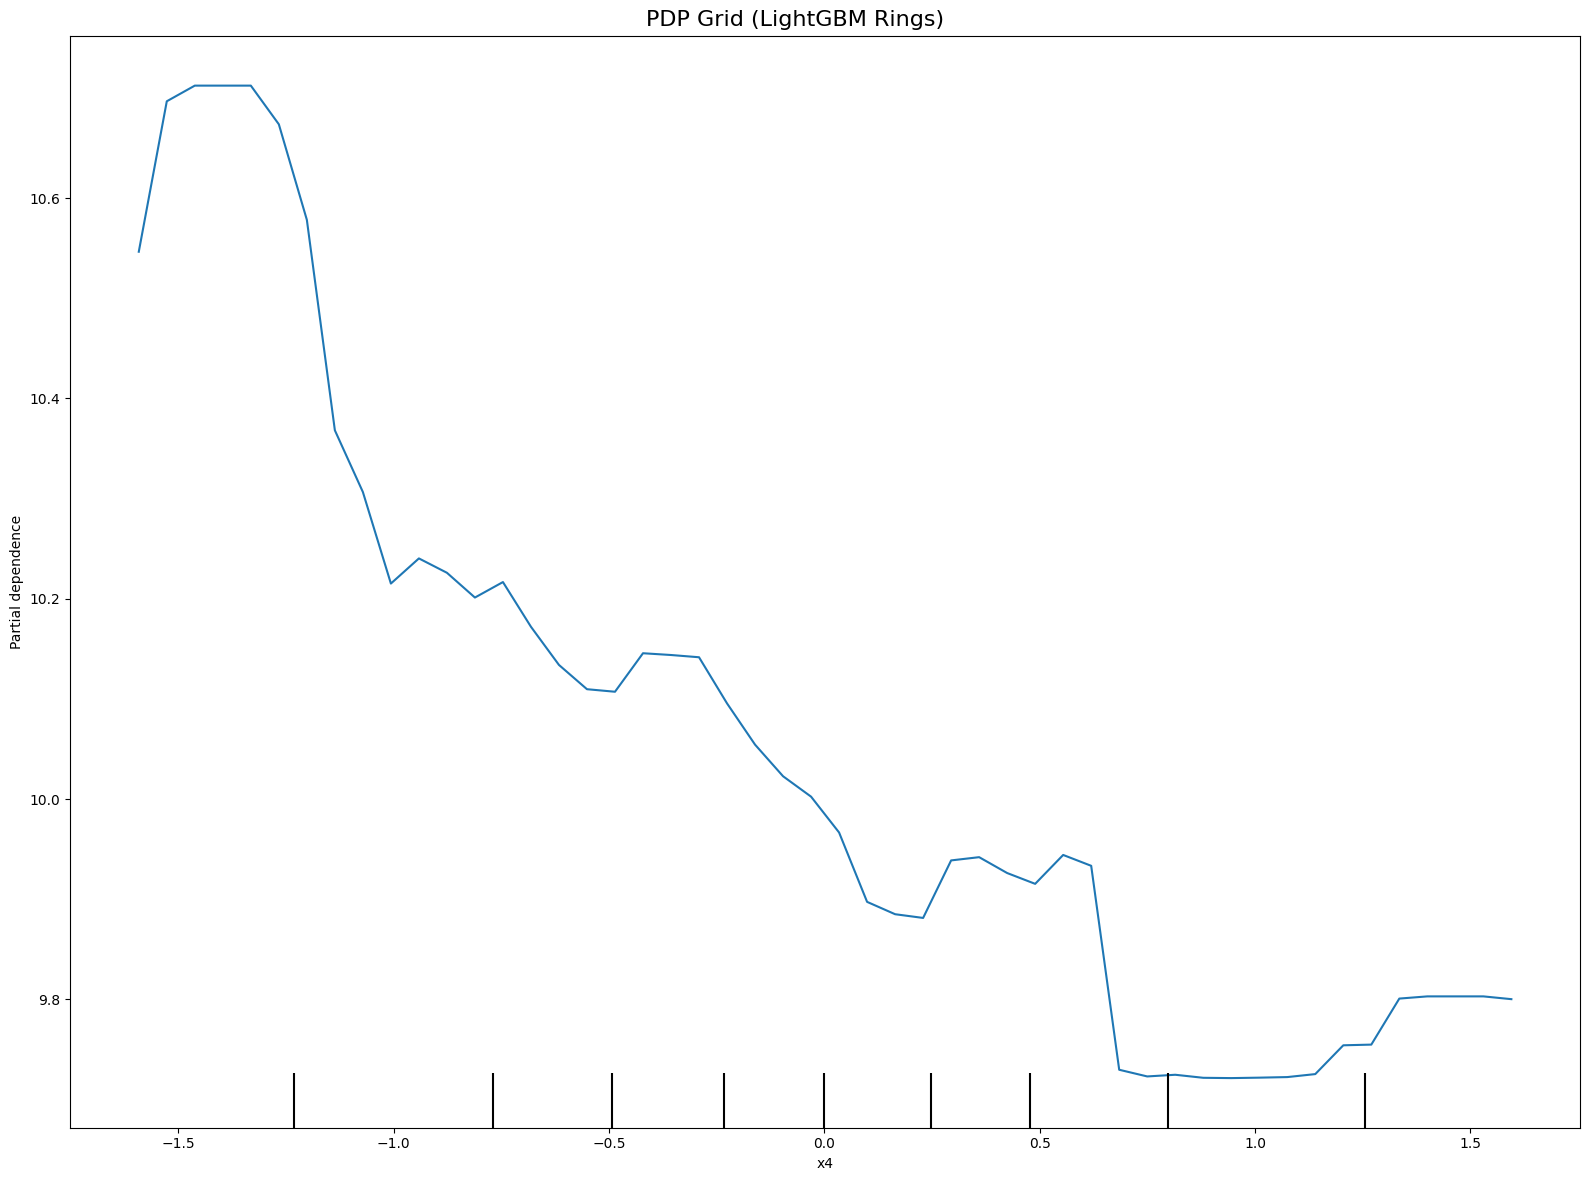

In [12]:
from sklearn.inspection import PartialDependenceDisplay

pdp_disp = PartialDependenceDisplay.from_estimator(
    lgb_model, X_train, features=[4],
    kind='average', grid_resolution=50  # Optional: control columns
)

# Customize the auto-created figure
fig = pdp_disp.figure_
fig.set_size_inches(16, 12)  # Zoom/enlarge
plt.subplots_adjust(wspace=0.4, hspace=0.4)  # Spacing
plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.08)  # Margins
plt.suptitle('PDP Grid (LightGBM Rings)', y=0.98, fontsize=16)
plt.tight_layout()
plt.show()


In [13]:
from sklearn.inspection import partial_dependence
pdp = partial_dependence(lgb_model, X_train, features=[4], percentiles=(0.0, 1.0), grid_resolution=100)
x_pdp = pdp.grid_values[0]  # Scaled x-grid
y_pdp = pdp.average[0]      # PDP y-values (avg predictions)


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

In [14]:
mask = x_pdp <= np.percentile(x_pdp, 95)
x_trim = x_pdp[mask]
y_trim = y_pdp[mask]

In [15]:
from scipy.optimize import differential_evolution

def piecewise_linear(x, breakpoint, slope1, int1, slope2, int2):
    return np.where(x < breakpoint, slope1 * x + int1, slope2 * x + int2)

def sse(params):
    breakpoint, slope1, int1, slope2, int2 = params
    y_pred = piecewise_linear(x_trim, breakpoint, slope1, int1, slope2, int2)
    return np.sum((y_trim - y_pred)**2)

# Bounds: adjust based on your scaled range (e.g., -2 to 1)
bounds = [(x_trim.min(), x_trim.max()), (-10,10), (-10,10), (-10,10), (-10,10)]
result = differential_evolution(sse, bounds, seed=42)
breakpoint_scaled = result.x[0]  # Detected breakpoint
print(f"Breakpoint (scaled): {breakpoint_scaled}")


Breakpoint (scaled): 3.5482316758348516


In [16]:
df_high_suck = df_encoded[df_encoded['Shucked weight'] > breakpoint_scaled * df_encoded['Shucked weight'].std() + df_encoded['Shucked weight'].mean()]
df_low_suck = df_encoded[df_encoded['Shucked weight'] < breakpoint_scaled * df_encoded['Shucked weight'].std() + df_encoded['Shucked weight'].mean()]

In [17]:
df_high_suck.shape

(0, 12)

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.41022
[200]	valid_0's rmse: 1.37994
Early stopping, best iteration is:
[186]	valid_0's rmse: 1.37738
RMSE: 1.3774, R²: 0.5026


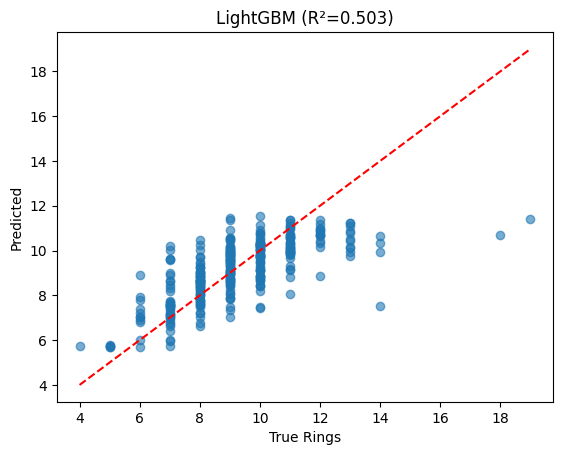

In [ ]:
best_params = study.best_params

best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model_high = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params
)

lgb_model_high.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = lgb_model_high.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()

[I 2026-01-23 01:36:49,524] A new study created in memory with name: no-name-28c9e10c-4147-4036-91d9-a45b003c9d0d
  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.535418:   2%|▏         | 1/50 [00:00<00:14,  3.48it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 1. Best value: 0.535892:   4%|▍         | 2/50 [00:00<00:08,  5.40it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 2. B

[I 2026-01-23 01:36:49,812] Trial 0 finished with value: 0.535418379669851 and parameters: {'num_leaves': 90, 'learning_rate': 0.014515165239298628, 'feature_fraction': 0.6588077876603874, 'bagging_fraction': 0.9651311448001039, 'bagging_freq': 1, 'min_child_samples': 11, 'reg_alpha': 4.568967011580715, 'reg_lambda': 4.312104622784171}. Best is trial 0 with value: 0.535418379669851.
[I 2026-01-23 01:36:49,926] Trial 1 finished with value: 0.5358917448161096 and parameters: {'num_leaves': 79, 'learning_rate': 0.021673194375959888, 'feature_fraction': 0.6087185507999878, 'bagging_fraction': 0.9902926443952286, 'bagging_freq': 1, 'min_child_samples': 23, 'reg_alpha': 1.0335045646990182, 'reg_lambda': 0.5906290253849056}. Best is trial 1 with value: 0.5358917448161096.
[I 2026-01-23 01:36:49,976] Trial 2 finished with value: 0.5389915040337225 and parameters: {'num_leaves': 132, 'learning_rate': 0.049633144486503904, 'feature_fraction': 0.6297892244584696, 'bagging_fraction': 0.95087057470

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.541054:   8%|▊         | 4/50 [00:00<00:04,  9.49it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.541054:   8%|▊         | 4/50 [00:00<00:04,  9.49it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.541054:  10%|█         | 5/50 [00:00<00:04,  9.49it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\util

[I 2026-01-23 01:36:50,040] Trial 3 finished with value: 0.5410541356539964 and parameters: {'num_leaves': 132, 'learning_rate': 0.02065234146558574, 'feature_fraction': 0.7376180982596354, 'bagging_fraction': 0.7442095122895581, 'bagging_freq': 7, 'min_child_samples': 55, 'reg_alpha': 3.1293074981138282, 'reg_lambda': 0.13769999168128655}. Best is trial 3 with value: 0.5410541356539964.
[I 2026-01-23 01:36:50,078] Trial 4 finished with value: 0.5361111058674355 and parameters: {'num_leaves': 68, 'learning_rate': 0.06818504403150814, 'feature_fraction': 0.8667413945636278, 'bagging_fraction': 0.884525779033414, 'bagging_freq': 6, 'min_child_samples': 81, 'reg_alpha': 0.2917565206836503, 'reg_lambda': 2.0839675203773917}. Best is trial 3 with value: 0.5410541356539964.
[I 2026-01-23 01:36:50,134] Trial 5 finished with value: 0.5395178271357018 and parameters: {'num_leaves': 115, 'learning_rate': 0.026047565078998615, 'feature_fraction': 0.8430370617113144, 'bagging_fraction': 0.87468291

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: 0.541511:  14%|█▍        | 7/50 [00:00<00:03, 13.01it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: 0.541511:  18%|█▊        | 9/50 [00:00<00:03, 12.52it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: 0.541511:  18%|█▊        | 9/50 [00:00<00:03, 12.52it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\util

...

[I 2026-01-23 01:36:52,846] Trial 42 finished with value: 0.5437060920652101 and parameters: {'num_leaves': 22, 'learning_rate': 0.0761269659904264, 'feature_fraction': 0.6182233715621572, 'bagging_fraction': 0.9378993279951646, 'bagging_freq': 3, 'min_child_samples': 52, 'reg_alpha': 4.4320189274080475, 'reg_lambda': 2.7361082377206265}. Best is trial 15 with value: 0.5439775115221714.
[I 2026-01-23 01:36:52,894] Trial 43 finished with value: 0.5357730786992669 and parameters: {'num_leaves': 23, 'learning_rate': 0.0757451419977856, 'feature_fraction': 0.6058799079870542, 'bagging_fraction': 0.9346548303707268, 'bagging_freq': 2, 'min_child_samples': 62, 'reg_alpha': 4.464308838179181, 'reg_lambda': 2.742659374789256}. Best is trial 15 with value: 0.5439775115221714.
[I 2026-01-23 01:36:52,942] Trial 44 finished with value: 0.5347496023013671 and parameters: {'num_leaves': 35, 'learning_rate': 0.07313845183765016, 'feature_fraction': 0.6371790952251314, 'bagging_fraction': 0.8573286725

Best trial: 15. Best value: 0.543978:  92%|█████████▏| 46/50 [00:03<00:00, 17.72it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 15. Best value: 0.543978:  96%|█████████▌| 48/50 [00:03<00:00, 17.88it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 15. Best value: 0.543978:  96%|█████████▌| 48/50 [00:03<00:00, 17.88it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 15. Best value: 0.543978: 100%|██████████| 50/50 [00:03<00:00, 13.5

[I 2026-01-23 01:36:53,048] Trial 46 finished with value: 0.5339345012634165 and parameters: {'num_leaves': 20, 'learning_rate': 0.08904306151568797, 'feature_fraction': 0.6608802787771909, 'bagging_fraction': 0.8787496275064055, 'bagging_freq': 4, 'min_child_samples': 67, 'reg_alpha': 3.7445465548201606, 'reg_lambda': 2.342157746338281}. Best is trial 15 with value: 0.5439775115221714.
[I 2026-01-23 01:36:53,116] Trial 47 finished with value: 0.5369613663066604 and parameters: {'num_leaves': 74, 'learning_rate': 0.030769957595150076, 'feature_fraction': 0.6683517120296162, 'bagging_fraction': 0.6617506318747951, 'bagging_freq': 3, 'min_child_samples': 57, 'reg_alpha': 4.148319158366306, 'reg_lambda': 1.4659704284104569}. Best is trial 15 with value: 0.5439775115221714.
[I 2026-01-23 01:36:53,174] Trial 48 finished with value: 0.5418619148983729 and parameters: {'num_leaves': 29, 'learning_rate': 0.06650221282700844, 'feature_fraction': 0.715205516821142, 'bagging_fraction': 0.98500665

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.39035
Early stopping, best iteration is:
[126]	valid_0's rmse: 2.38928
RMSE: 2.3893, R²: 0.5440


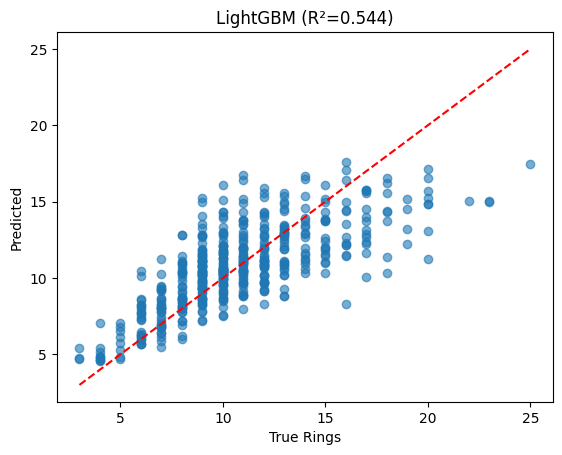

In [ ]:
X = df_low_suck.drop(columns = 'Rings')
y = df_low_suck['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best R² on validation:", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params

best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model_low = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params
)

lgb_model_low.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = lgb_model_low.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()